# Substructure SNR figures

Reads the per-band outputs produced by `substructure_snr_histogram.py`:

* `substructure_snr_<band>.npy` — SNR values (one per system that succeeded)
* `substructure_snr_<band>_uids.npy` — matching UIDs
* `substructure_snr_failures_<band>.json` — `{uid: error}` for failed/skipped systems

and produces:

1. Summary table (count ok / failed, median, mean, max, percentiles)
2. Per-band histogram (log-x, log-y)
3. Overlay of all bands on shared axes
4. ECDF per band
5. Failure-mode breakdown bar chart

In [9]:
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

Update `analysis_dir` to point at the `analysis/` directory written by the script.

In [10]:
analysis_dir = '/data/bwedig/mejiro/roman_data_challenge_rung_1/analysis'  # TODO update
# bands = ['F106', 'F129', 'F158']
bands = ['F129']
fig_dir = os.path.join(analysis_dir, 'figures')
os.makedirs(fig_dir, exist_ok=True)

## Load arrays

In [11]:
snr_by_band = {}
uids_by_band = {}
failures_by_band = {}

for band in bands:
    snr_path = os.path.join(analysis_dir, f'substructure_snr_{band}.npy')
    uid_path = os.path.join(analysis_dir, f'substructure_snr_{band}_uids.npy')
    fail_path = os.path.join(analysis_dir, f'substructure_snr_failures_{band}.json')
    if not os.path.exists(snr_path):
        print(f'[{band}] missing {snr_path}, skipping')
        continue
    snr_by_band[band] = np.load(snr_path)
    uids_by_band[band] = np.load(uid_path, allow_pickle=True)
    with open(fail_path) as f:
        failures_by_band[band] = json.load(f)
    print(f'[{band}] ok={len(snr_by_band[band])}  fail/skip={len(failures_by_band[band])}')

[F129] ok=5114  fail/skip=0


## Summary statistics

In [12]:
header = f'{"band":<6} {"N":>6} {"median":>10} {"mean":>10} {"p84":>10} {"p95":>10} {"max":>10}'
print(header)
print('-' * len(header))
for band, vals in snr_by_band.items():
    if len(vals) == 0:
        continue
    print(f'{band:<6} {len(vals):>6d} '
          f'{np.median(vals):>10.3f} {np.mean(vals):>10.3f} '
          f'{np.percentile(vals, 84):>10.3f} {np.percentile(vals, 95):>10.3f} '
          f'{np.max(vals):>10.3f}')

band        N     median       mean        p84        p95        max
--------------------------------------------------------------------
F129     5114      6.842     12.150     20.034     38.485    314.150


## Per-band histogram (log-x, log-y)

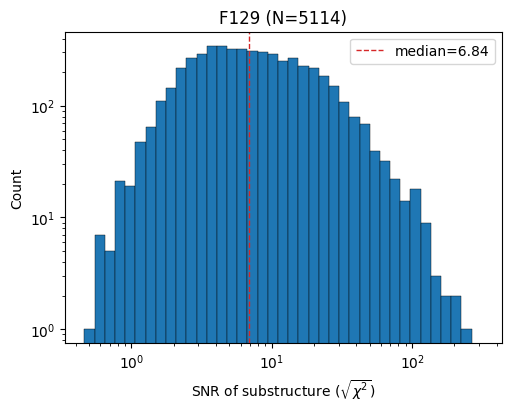

In [13]:
n_bands = len(snr_by_band)
fig, axes = plt.subplots(1, n_bands, figsize=(5 * n_bands, 4), constrained_layout=True)
if n_bands == 1:
    axes = [axes]

for ax, (band, vals) in zip(axes, snr_by_band.items()):
    lo = max(float(vals.min()), 0.1)
    hi = float(vals.max())
    bins = np.logspace(np.log10(lo), np.log10(hi), 40) if hi > lo else 40
    ax.hist(vals, bins=bins, color='C0', edgecolor='black', linewidth=0.3)
    if isinstance(bins, np.ndarray):
        ax.set_xscale('log')
    ax.set_yscale('log')
    ax.axvline(np.median(vals), color='C3', linestyle='--', linewidth=1,
               label=f'median={np.median(vals):.2f}')
    ax.set_xlabel(r'SNR of substructure ($\sqrt{\chi^2}$)')
    ax.set_ylabel('Count')
    ax.set_title(f'{band} (N={len(vals)})')
    ax.legend()

fig.savefig(os.path.join(fig_dir, 'substructure_snr_hist_per_band.png'), dpi=150)
plt.show()

## Overlay of all bands

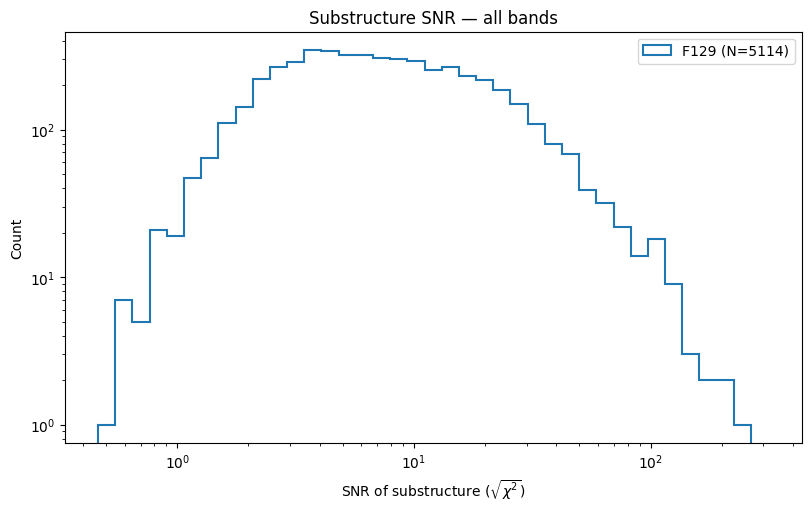

In [14]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

all_vals = np.concatenate(list(snr_by_band.values())) if snr_by_band else np.array([])
lo = max(float(all_vals.min()), 0.1)
hi = float(all_vals.max())
bins = np.logspace(np.log10(lo), np.log10(hi), 40)

for band, vals in snr_by_band.items():
    ax.hist(vals, bins=bins, histtype='step', linewidth=1.5,
            label=f'{band} (N={len(vals)})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'SNR of substructure ($\sqrt{\chi^2}$)')
ax.set_ylabel('Count')
ax.set_title('Substructure SNR — all bands')
ax.legend()

fig.savefig(os.path.join(fig_dir, 'substructure_snr_hist_overlay.png'), dpi=150)
plt.show()

## ECDF per band

Fraction of systems with substructure SNR below a given value — useful for picking a detection threshold.

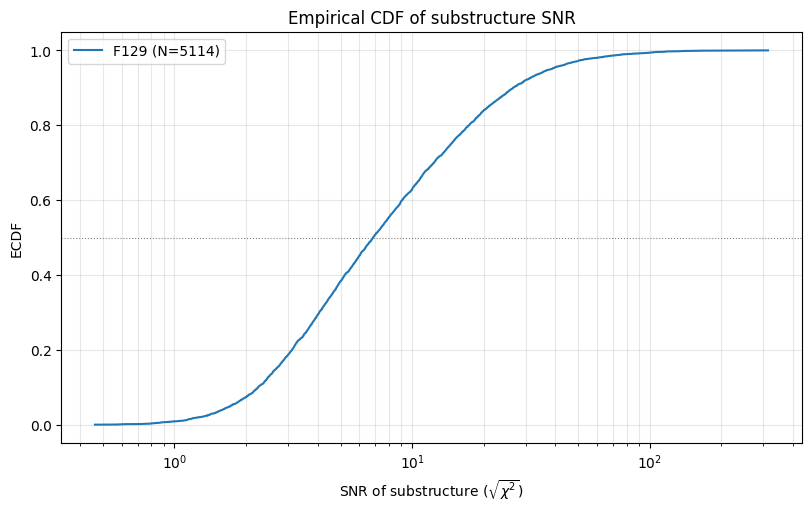

In [15]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for band, vals in snr_by_band.items():
    sv = np.sort(vals)
    y = np.arange(1, len(sv) + 1) / len(sv)
    ax.plot(sv, y, label=f'{band} (N={len(sv)})')

ax.set_xscale('log')
ax.set_xlabel(r'SNR of substructure ($\sqrt{\chi^2}$)')
ax.set_ylabel('ECDF')
ax.set_title('Empirical CDF of substructure SNR')
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
ax.grid(True, which='both', alpha=0.3)
ax.legend()

fig.savefig(os.path.join(fig_dir, 'substructure_snr_ecdf.png'), dpi=150)
plt.show()

## Failure / skip breakdown

Collapses similar error messages into categories and counts them per band.

In [16]:
def categorize(err):
    if err is None:
        return 'unknown'
    s = str(err)
    if 'macromodel missing' in s:
        return 'no macromodel backup (skipped)'
    if 'snr array all non-finite' in s:
        return 'snr array non-finite'
    if 'snr threshold non-finite' in s:
        return 'snr threshold non-finite'
    if 'mask too small' in s:
        return 'mask too small'
    if 'zero in chi2 denominator' in s:
        return 'zero in chi2 denominator'
    if 'bad chi2' in s:
        return 'bad chi2'
    if 'worker crash' in s:
        return 'worker crash'
    if 'AttributeError' in s:
        return 'AttributeError'
    if 'RuntimeError' in s:
        return 'RuntimeError (other)'
    return 'other'

categories = sorted({categorize(e) for fails in failures_by_band.values() for e in fails.values()})
if not categories:
    print('No failures recorded.')
else:
    counts = {band: Counter(categorize(e) for e in failures_by_band[band].values())
              for band in failures_by_band}
    x = np.arange(len(categories))
    width = 0.8 / max(len(counts), 1)
    fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(categories)), 5),
                           constrained_layout=True)
    for i, (band, c) in enumerate(counts.items()):
        heights = [c.get(cat, 0) for cat in categories]
        ax.bar(x + i * width, heights, width, label=band)
    ax.set_xticks(x + width * (len(counts) - 1) / 2)
    ax.set_xticklabels(categories, rotation=25, ha='right')
    ax.set_ylabel('Count')
    ax.set_title('Failure / skip categories by band')
    ax.legend()
    fig.savefig(os.path.join(fig_dir, 'substructure_snr_failures.png'), dpi=150)
    plt.show()

No failures recorded.
